## Global_Music_Streaming_Listener_Preferences

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
df = pd.read_csv('Global_Music_Streaming_Listener_Preferences (2).csv')

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 13 columns):
 #   Column                                    Non-Null Count  Dtype   
---  ------                                    --------------  -----   
 0   User_ID                                   5000 non-null   object  
 1   Age                                       5000 non-null   int64   
 2   Country                                   5000 non-null   object  
 3   Streaming Platform                        5000 non-null   object  
 4   Top Genre                                 5000 non-null   object  
 5   Minutes Streamed Per Day                  5000 non-null   int64   
 6   Number of Songs Liked                     5000 non-null   int64   
 7   Most Played Artist                        5000 non-null   object  
 8   Subscription Type                         5000 non-null   object  
 9   Listening Time (Morning/Afternoon/Night)  5000 non-null   object  
 10  Discover Weekly Engageme

In [11]:
df.dtypes

,0
User_ID,object
Age,int64
Country,object
Streaming Platform,object
Top Genre,object
Minutes Streamed Per Day,int64
Number of Songs Liked,int64
Most Played Artist,object
Subscription Type,object
Listening Time (Morning/Afternoon/Night),object


In [6]:
df.head(5)

,User_ID,Age,Country,Streaming Platform,Top Genre,Minutes Streamed Per Day,Number of Songs Liked,Most Played Artist,Subscription Type,Listening Time (Morning/Afternoon/Night),Discover Weekly Engagement (%),Repeat Song Rate (%)
0,U1000,34,Japan,Tidal,Reggae,295,138,Adele,Free,Afternoon,47.42,16.74
1,U1001,24,Germany,Deezer,Country,86,388,Ed Sheeran,Premium,Night,12.06,69.25
2,U1002,49,Germany,Deezer,Pop,363,368,Post Malone,Premium,Afternoon,47.19,67.38
3,U1003,55,Australia,YouTube,Reggae,348,349,Dua Lipa,Premium,Morning,31.27,76.51
4,U1004,13,Germany,Amazon Music,Reggae,30,328,Adele,Free,Night,30.68,43.41


In [7]:
df.isna().sum()

,0
User_ID,0
Age,0
Country,0
Streaming Platform,0
Top Genre,0
Minutes Streamed Per Day,0
Number of Songs Liked,0
Most Played Artist,0
Subscription Type,0
Listening Time (Morning/Afternoon/Night),0


In [8]:
df.dropna(axis =1)

,User_ID,Age,Country,Streaming Platform,Top Genre,Minutes Streamed Per Day,Number of Songs Liked,Most Played Artist,Subscription Type,Listening Time (Morning/Afternoon/Night),Discover Weekly Engagement (%),Repeat Song Rate (%)
0,U1000,34,Japan,Tidal,Reggae,295,138,Adele,Free,Afternoon,47.42,16.74
1,U1001,24,Germany,Deezer,Country,86,388,Ed Sheeran,Premium,Night,12.06,69.25
2,U1002,49,Germany,Deezer,Pop,363,368,Post Malone,Premium,Afternoon,47.19,67.38
3,U1003,55,Australia,YouTube,Reggae,348,349,Dua Lipa,Premium,Morning,31.27,76.51
4,U1004,13,Germany,Amazon Music,Reggae,30,328,Adele,Free,Night,30.68,43.41
...,...,...,...,...,...,...,...,...,...,...,...,...
4995,U5995,60,UK,Deezer,Country,348,81,Post Malone,Premium,Morning,49.23,22.36
4996,U5996,38,Australia,Deezer,Hip-Hop,225,218,BTS,Premium,Night,17.08,58.23
4997,U5997,27,Brazil,Amazon Music,Metal,568,277,Taylor Swift,Premium,Night,69.39,51.71
4998,U5998,58,Canada,Amazon Music,EDM,523,492,Bad Bunny,Premium,Night,43.44,24.53


In [9]:
df.duplicated().sum()

np.int64(0)

In [15]:
### Step 1: Data Quality Checks

print(df.isnull().sum())
print('Duplicate User_IDs:', df.duplicated(subset='User_ID').sum())
for col in ['Country','Streaming Platform','Top Genre','Subscription Type',
            'Listening Time (Morning/Afternoon/Night)']:
    print(col, '->', df[col].nunique(), 'unique values')

User_ID                                     0
Age                                         0
Country                                     0
Streaming Platform                          0
Top Genre                                   0
Minutes Streamed Per Day                    0
Number of Songs Liked                       0
Most Played Artist                          0
Subscription Type                           0
Listening Time (Morning/Afternoon/Night)    0
Discover Weekly Engagement (%)              0
Repeat Song Rate (%)                        0
dtype: int64
Duplicate User_IDs: 0
Country -> 10 unique values
Streaming Platform -> 6 unique values
Top Genre -> 10 unique values
Subscription Type -> 2 unique values
Listening Time (Morning/Afternoon/Night) -> 3 unique values


In [16]:
### Step 2: Feature Engineering - Age Groups

bins = [17,25,35,45,55,65]
labels = ['18-25','26-35','36-45','46-55','56-65']
df['Age Group'] = pd.cut(df['Age'], bins=bins, labels=labels)
df['Age Group'].value_counts().sort_index()

,count
Age Group,
18-25,799
26-35,1067
36-45,1055
46-55,1032
56-65,535


Streaming Platform
Amazon Music    861
Tidal           850
Deezer          844
Spotify         827
YouTube         822
Apple Music     796
Name: count, dtype: int64


/tmp/ipykernel_3907/763213726.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=platform_counts.index, y=platform_counts.values, palette='viridis')


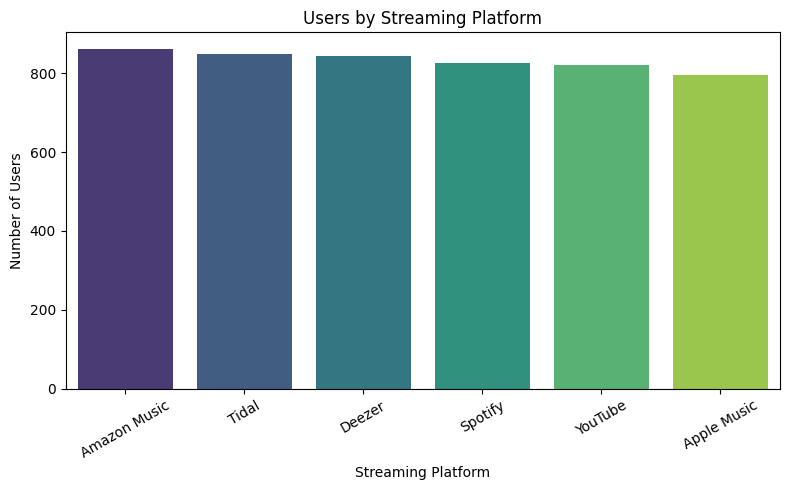

In [17]:
# ## Q1: What are the most popular music streaming platforms?

platform_counts = df['Streaming Platform'].value_counts()
print(platform_counts)

plt.figure(figsize=(8,5))
sns.barplot(x=platform_counts.index, y=platform_counts.values, palette='viridis')
plt.title('Users by Streaming Platform')
plt.ylabel('Number of Users')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

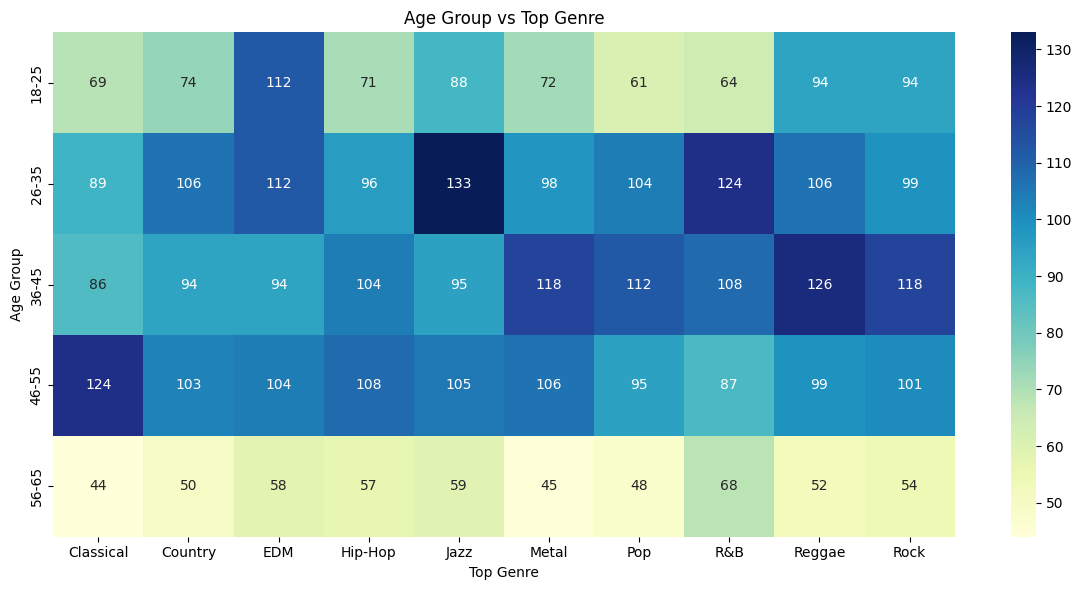

Top genre per age group:
Age Group
18-25          EDM
26-35         Jazz
36-45       Reggae
46-55    Classical
56-65          R&B
Name: Top Genre, dtype: object

Avg minutes streamed by age group:
Age Group
18-25    315.1
26-35    302.9
36-45    315.7
46-55    302.6
56-65    316.3
Name: Minutes Streamed Per Day, dtype: float64


/tmp/ipykernel_3907/1955409896.py:11: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(df.groupby('Age Group')['Top Genre'].agg(lambda x: x.value_counts().index[0]))
/tmp/ipykernel_3907/1955409896.py:14: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(df.groupby('Age Group')['Minutes Streamed Per Day'].mean().round(1))


In [18]:
### Q2: How does age impact music preferences?

age_genre = pd.crosstab(df['Age Group'], df['Top Genre'])
plt.figure(figsize=(12,6))
sns.heatmap(age_genre, cmap='YlGnBu', annot=True, fmt='d')
plt.title('Age Group vs Top Genre')
plt.tight_layout()
plt.show()

print('Top genre per age group:')
print(df.groupby('Age Group')['Top Genre'].agg(lambda x: x.value_counts().index[0]))

print('\nAvg minutes streamed by age group:')
print(df.groupby('Age Group')['Minutes Streamed Per Day'].mean().round(1))

/tmp/ipykernel_3907/713998503.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=genre_counts.values, y=genre_counts.index, ax=axes[0], palette='magma')
/tmp/ipykernel_3907/713998503.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=artist_counts.values[:10], y=artist_counts.index[:10], ax=axes[1], palette='rocket')


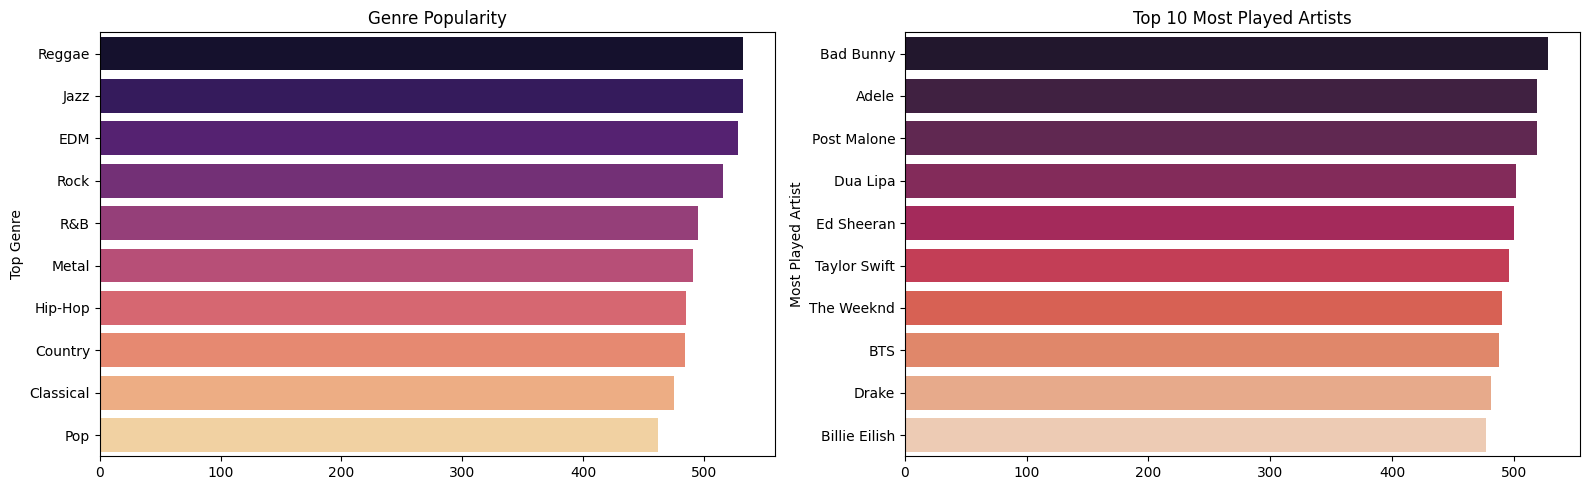

In [19]:
## Q3: What are the most streamed genres and artists?

genre_counts = df['Top Genre'].value_counts()
artist_counts = df['Most Played Artist'].value_counts()

fig, axes = plt.subplots(1,2, figsize=(16,5))
sns.barplot(x=genre_counts.values, y=genre_counts.index, ax=axes[0], palette='magma')
axes[0].set_title('Genre Popularity')
sns.barplot(x=artist_counts.values[:10], y=artist_counts.index[:10], ax=axes[1], palette='rocket')
axes[1].set_title('Top 10 Most Played Artists')
plt.tight_layout()
plt.show()

                   Minutes Streamed Per Day  Discover Weekly Engagement (%)  \
Subscription Type                                                             
Free                                 309.58                           50.58   
Premium                              308.90                           50.01   

                   Repeat Song Rate (%)  Number of Songs Liked  
Subscription Type                                               
Free                              42.77                 255.52  
Premium                           42.02                 251.55  


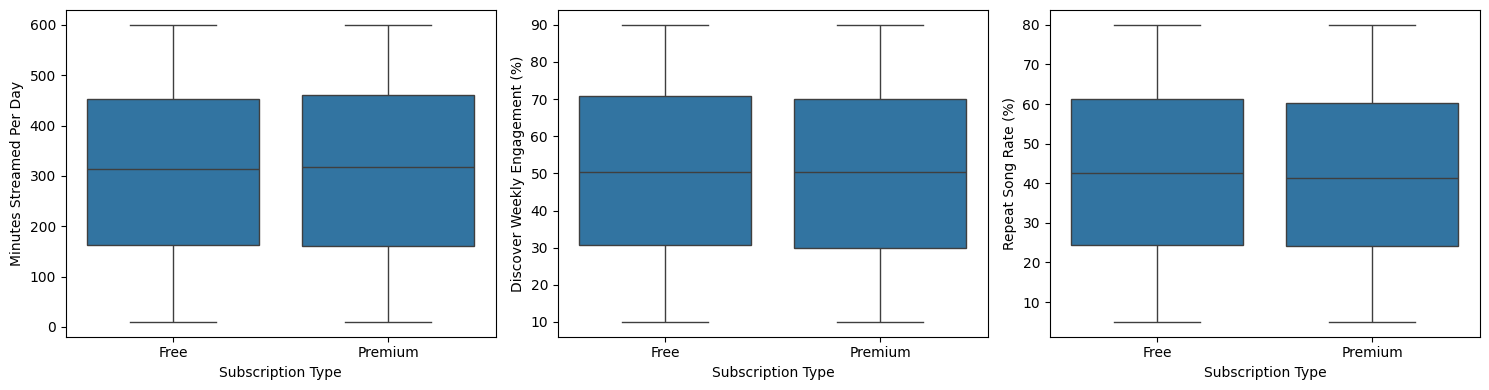

In [20]:
# ## Q4: How do free vs. premium users differ in streaming behavior?

sub_compare = df.groupby('Subscription Type')[['Minutes Streamed Per Day',
    'Discover Weekly Engagement (%)','Repeat Song Rate (%)','Number of Songs Liked']].mean().round(2)
print(sub_compare)

fig, axes = plt.subplots(1,3, figsize=(15,4))
sns.boxplot(x='Subscription Type', y='Minutes Streamed Per Day', data=df, ax=axes[0])
sns.boxplot(x='Subscription Type', y='Discover Weekly Engagement (%)', data=df, ax=axes[1])
sns.boxplot(x='Subscription Type', y='Repeat Song Rate (%)', data=df, ax=axes[2])
plt.tight_layout()
plt.show()

Listening Time (Morning/Afternoon/Night)
Night        1745
Afternoon    1634
Morning      1621
Name: count, dtype: int64


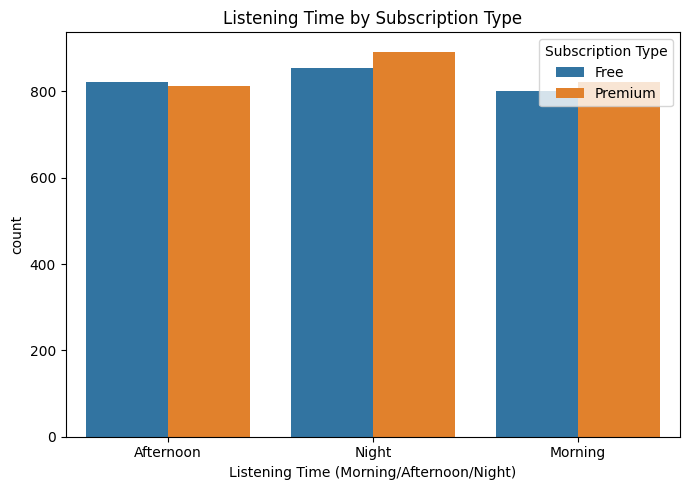

In [21]:
## Q5: What time of day do users stream music the most?

time_counts = df['Listening Time (Morning/Afternoon/Night)'].value_counts()
print(time_counts)

plt.figure(figsize=(7,5))
sns.countplot(x='Listening Time (Morning/Afternoon/Night)', hue='Subscription Type', data=df)
plt.title('Listening Time by Subscription Type')
plt.tight_layout()
plt.show()


Top genre by country:
Country
Australia         Pop
Brazil           Rock
Canada            EDM
France           Jazz
Germany           EDM
India          Reggae
Japan            Jazz
South Korea      Rock
UK             Reggae
USA               EDM
Name: Top Genre, dtype: object

Avg minutes streamed by country:
Country
Germany        322.0
France         318.6
South Korea    316.2
Australia      314.9
UK             309.8
Canada         307.7
Japan          306.6
India          305.5
USA            297.4
Brazil         293.7
Name: Minutes Streamed Per Day, dtype: float64

Premium adoption % by country:
Country
Canada         52.9
UK             52.3
France         51.3
USA            50.8
Brazil         50.6
Japan          50.5
South Korea    49.8
Germany        49.7
Australia      49.0
India          48.2
Name: Subscription Type, dtype: float64


/tmp/ipykernel_3907/1386543207.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=avg_minutes_country.index, y=avg_minutes_country.values, palette='crest')


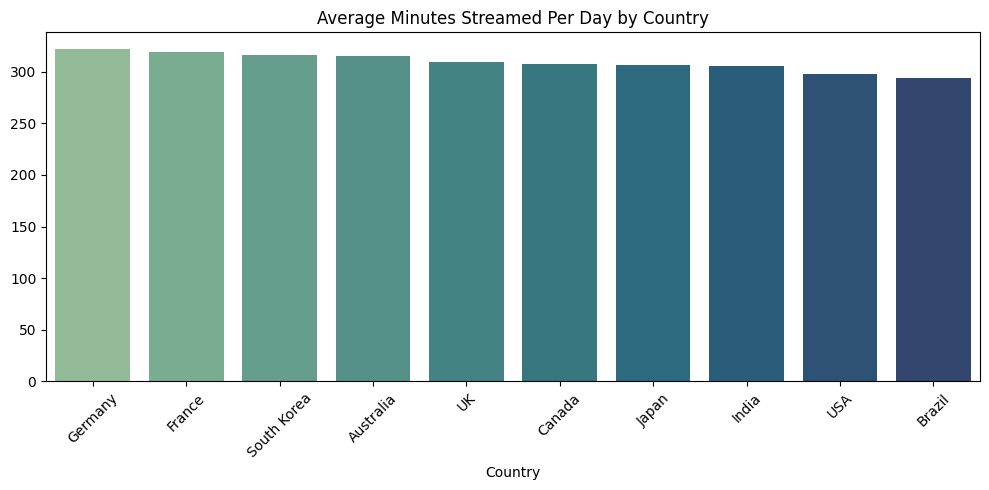

In [22]:
# ## Q6: Are there any regional trends in music streaming preferences?

print('Top genre by country:')
print(df.groupby('Country')['Top Genre'].agg(lambda x: x.value_counts().index[0]))

avg_minutes_country = df.groupby('Country')['Minutes Streamed Per Day'].mean().sort_values(ascending=False)
print('\nAvg minutes streamed by country:')
print(avg_minutes_country.round(1))

premium_pct = df.groupby('Country')['Subscription Type'].apply(lambda x: (x=='Premium').mean()*100).round(1)
print('\nPremium adoption % by country:')
print(premium_pct.sort_values(ascending=False))

plt.figure(figsize=(10,5))
sns.barplot(x=avg_minutes_country.index, y=avg_minutes_country.values, palette='crest')
plt.title('Average Minutes Streamed Per Day by Country')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

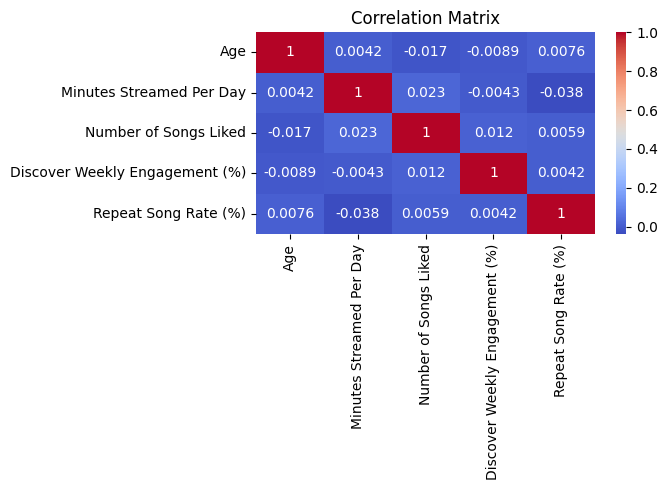

In [23]:
 ## Step 3: Correlation Analysis

numeric_cols = ['Age','Minutes Streamed Per Day','Number of Songs Liked',
                'Discover Weekly Engagement (%)','Repeat Song Rate (%)']
plt.figure(figsize=(7,5))
sns.heatmap(df[numeric_cols].corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Matrix')
plt.tight_layout()
plt.show()

In [24]:
# ## Step 4: Export Cleaned Data for Power BI

df.to_csv('cleaned_music_data.csv', index=False)
print('Exported cleaned_music_data.csv - use this as the Power BI data source.')

Exported cleaned_music_data.csv - use this as the Power BI data source.
